In [1]:
import os
import sys
import argparse

import matplotlib.pyplot as plt

from data import *
from utils import *
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig
from TCM import compute_tcm

from BA import oh_binary_accuracy

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=10_000, help='Total # of samples')                     # Maybe 10_000
parser.add_argument('--mb_size', type=int, default=128, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=24, help='Dim of latent vector')                   # Maybe 16, 32
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')   # Maybe 16, 48 or 64 if too blurry
parser.add_argument('--x_fdim', type=int, default=48, help='Input x_fdim. See utils.py')            # Maybe 96 or 128
parser.add_argument('--y_fdim', type=int, default=16, help='Input y_fdim. See utils.py')            # Maybe 10, 16, 20, 32
parser.add_argument('--c_accu', type=float, default=25, help='Input weight on recons_error')        # Maybe 10, 25, 50, 100

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')     # Maybe 3e-4, 1e-4, 5e-5
parser.add_argument('--max_epochs', type=int, default=0, help='Input max_epoch for cut-off') # 500
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=True, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
xtrain, xtest, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [5]:
def kPCA(X, eps=1e-6):
    a = X @ X.T
    B = a.size(0)

    oneN = torch.ones(B, B, device=a.device, dtype=a.dtype) / B
    a = a - oneN @ a - a @ oneN + oneN @ a @ oneN

    a = 0.5 * (a + a.T)  # numerical symmetry
    a = a + eps * torch.eye(B, device=a.device, dtype=a.dtype)

    evals, evecs = torch.linalg.eigh(a)
    idx = torch.argsort(evals, descending=True)
    evals = evals[idx]
    evecs = evecs[:, idx]

    return evecs[:, :opt.h_dim], evals

In [6]:
def rkm_loss(output1, X):
    h, s = kPCA(output1)
    U = torch.mm(output1.t(), h)

    x_tilde = net3(torch.mm(h, U.t()))

    # Costs
    f1 = torch.trace(torch.mm(torch.mm(output1, U), h.t()))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:opt.h_dim]), h.t())))
    f3 = 0.5 * torch.trace(torch.mm(U.t(), U))

    # Reconstruction losses
    mse = torch.nn.MSELoss()
    img_loss = mse(x_tilde.view(-1, ipVec_dim), X.view(-1, ipVec_dim))

    f4 = img_loss

    loss = -f1 + f3 + f2 + 0.5 * (-f1 + f3 + f2) ** 2 + opt.c_accu * f4
    return loss

In [7]:
net1 = Net1(opt).double().to(opt.device)
net3 = Net3(opt).double().to(opt.device)

In [8]:
params = list(net1.parameters()) + list(net3.parameters())
optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=0)
loss_history = []

In [9]:
# l_cost = 6  # Costs from where checkpoints will be saved
# t = 1
# cost = np.inf  # Initialize cost
# start = datetime.now()
# global_step = 0

# while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
#     avg_loss = 0
#     for i, (datax, datay) in enumerate(xtrain):
#         if i < math.ceil(opt.N / opt.mb_size):
#             datax = datax.to(opt.device)
#             output1 = net1(datax)

#             loss = rkm_loss(output1, datax)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             global_step += 1
#             avg_loss += loss.detach().cpu().numpy()
#         else:
#             break
#     cost = avg_loss

#     # Remember lowest cost and save checkpoint
#     is_best = cost < l_cost
#     l_cost = min(cost, l_cost)

#     dirs.save_checkpoint({
#         'epochs': t + 1,
#         'net1_state_dict': net1.state_dict(),
#         'net3_state_dict': net3.state_dict(),
#         'l_cost': l_cost,
#         'optimizer': optimizer.state_dict()}, is_best)
        
#     print(t, cost)
#     t += 1
#     loss_history.append(cost)

# print('Finished Training in: {}. Lowest cost: {}'.format(str(datetime.now() - start), l_cost))

In [10]:
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net1.load_state_dict(sd_mdl['net1_state_dict'])
#     net3.load_state_dict(sd_mdl['net3_state_dict'])

# U, h, s = final_compute_1V(opt, net1, kPCA)

In [11]:
# torch.save({'net1': net1,
#             'net3': net3,

#             'net1_state_dict': net1.state_dict(),
#             'net3_state_dict': net3.state_dict(),

#             'datax': datax,
#             'datay': datay,

#             'h': h,
#             'opt': opt, 's': s, 'U': U}, 'out/{}'.format(dirs.dirout))

In [12]:
model = torch.load('out/Final-1V.tar', weights_only=False)

U = model['U']
h = model['h']
s = model['s']

net1 = model['net1']
net3 = model['net3']

datax = model['datax']

## Evaluation

In [13]:
all_im_en = []

all_data_im = []
all_data_la = []

with torch.no_grad():
    for datax, datay in xtest:
        datax = datax.to(opt.device)
        output1 = net1(datax)
        all_im_en.append(output1.cpu())
        
        all_data_im.append(datax.cpu())
        all_data_la.append(datay.cpu())

In [14]:
all_im_en = torch.cat(all_im_en, dim=0)[:1000]

all_data_im = torch.cat(all_data_im, dim=0)[:1000]
all_data_la = torch.cat(all_data_la, dim=0)[:1000]

In [15]:
with torch.no_grad():
    h_test, _ = kPCA(all_im_en)
    U_test = all_im_en.t() @ h_test
    x_im_tilde_test = net3(h_test @ U_test.T)

In [16]:
recon_loss = torch.nn.MSELoss()

loss_im_all = recon_loss(x_im_tilde_test.view(-1, ipVec_dim), all_data_im.view(-1, ipVec_dim)).item()

print('Reconstruction loss (MSE) on test set: {:.4f}'.format(loss_im_all))

Reconstruction loss (MSE) on test set: 0.0076


## Visual Inspection

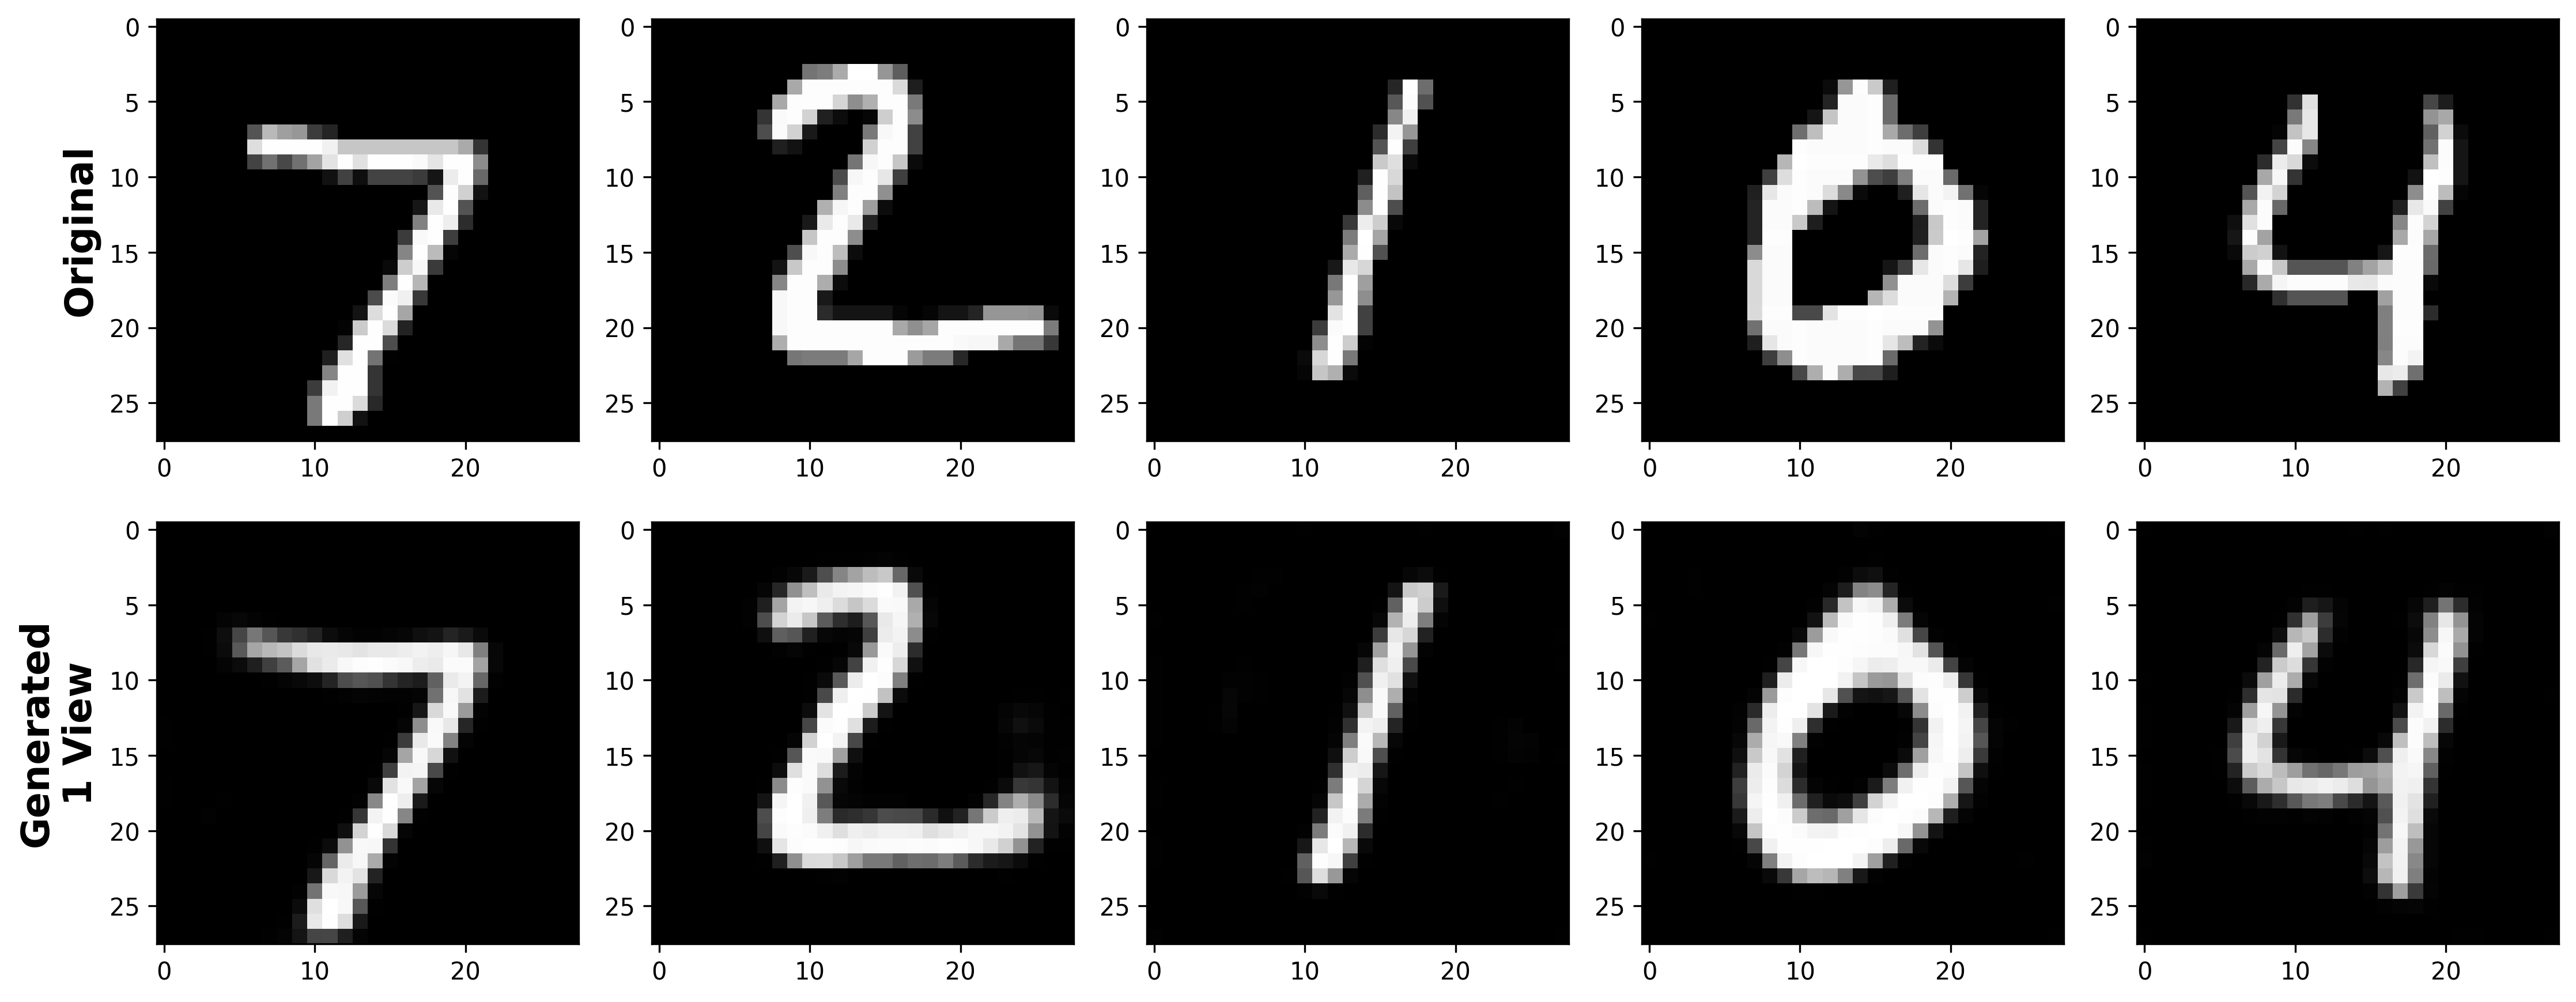

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6), dpi=300)

for idx in range(5):    
    axes[0, 0].set_ylabel('\nOriginal', fontsize=16, fontweight='bold')
    axes[1, 0].set_ylabel('Generated\n1 View', fontsize=16, fontweight='bold')

    axes[0, idx].imshow(all_data_im[idx][0].reshape(28, 28), cmap='gray')

    axes[1, idx].imshow(x_im_tilde_test[idx][0].reshape(28, 28), cmap='gray')

plt.tight_layout()
plt.savefig('img/genrkm_mnist_sv_comp.png', dpi=300)
plt.show()

## Disentanglement

In [18]:
C = h_test
Z = all_data_la

factor_types = ['discrete'] * 10

In [19]:
C.shape, Z.shape

(torch.Size([1000, 24]), torch.Size([1000, 10]))

In [20]:
res = compute_dci(C, Z, factor_types, probe="lasso")
report_dci(res, title='Combined DCI Scores')

--- Combined DCI Scores ---
 > Disentanglement: 0.1255
 > Completeness: 0.1486
 > Informativeness: 0.97


- Low D & C -> Did not to learn to store digits based on value, it **organized its latent space around other factors**
- High I -> The representation did store the digits wellI men

-> Other scores must be used

## IRS

In [21]:
irs_results = compute_irs(C, Z)

print(f'--- IRS Scores ---')
print(f' > IRS Disentanglement: {round(irs_results["IRS"], 4)}')

--- IRS Scores ---
 > IRS Disentanglement: 0.2689


### MIG

In [22]:
mig_res = compute_mig(C, Z)
print(f'--- MIG Scores ---')
print(f' > MIG: {round(mig_res["MIG"], 4)}')

--- MIG Scores ---
 > MIG: 0.0586


In [23]:
tcm_results = compute_tcm(Z.cpu().numpy(), C.cpu().numpy())

print(f'--- TCM Scores ---')
print(f' > TCM: {round(tcm_results, 4)}')

--- TCM Scores ---
 > TCM: 0.0272


## Other Generative Factors

In [24]:
def extract_mnist_factors(img, threshold=0.1):
    """
    img: 2D numpy array, shape (H, W), assumed scaled to [0, 1]
    returns: dict of proxy generating factors
    """
    H, W = img.shape
    ys, xs = np.indices((H, W))

    mask = img > threshold
    if mask.sum() == 0:
        return {
            "x_center": 0.0,
            "y_center": 0.0,
            "width": 0.0,
            "height": 0.0,
            "area": 0.0,
            "angle": 0.0,
        }

    weights = img * mask
    total = weights.sum()

    x_center = (xs * weights).sum() / total
    y_center = (ys * weights).sum() / total

    x_active = xs[mask]
    y_active = ys[mask]
    width = x_active.max() - x_active.min() + 1
    height = y_active.max() - y_active.min() + 1
    area = mask.sum()

    # weighted covariance for principal orientation
    x_shift = xs - x_center
    y_shift = ys - y_center
    cov_xx = (weights * x_shift * x_shift).sum() / total
    cov_yy = (weights * y_shift * y_shift).sum() / total
    cov_xy = (weights * x_shift * y_shift).sum() / total

    angle = 0.5 * np.arctan2(2 * cov_xy, cov_xx - cov_yy)
    return [x_center, y_center, width, height, area, angle]
    # return {
    #     "x_center": float(x_center),
    #     "y_center": float(y_center),
    #     "width": float(width),
    #     "height": float(height),
    #     "area": float(area),
    #     "angle": float(angle),
    # }

In [25]:
def discretize_factors(F, n_bins=10):
    F = np.asarray(F, dtype=float)
    F_disc = np.zeros_like(F, dtype=int)

    for j in range(F.shape[1]):
        x = F[:, j]

        # If constant, keep all zero
        if np.allclose(x, x[0]):
            F_disc[:, j] = 0
            continue

        edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
        edges = np.unique(edges)

        if len(edges) <= 2:
            F_disc[:, j] = 0
        else:
            F_disc[:, j] = np.digitize(x, edges[1:-1], right=False)

    return F_disc

In [26]:
calculated_factors = [extract_mnist_factors(img.cpu().numpy().reshape(28, 28)) for img in all_data_im]
gen_factors_disc = discretize_factors(calculated_factors, n_bins=10)
factor_types = ['continuous'] * 6

In [27]:
res = compute_dci(C, calculated_factors, factor_types, probe="rf")
report_dci(res, title='DCI Scores')

--- DCI Scores ---
 > Disentanglement: 0.241
 > Completeness: 0.221
 > Informativeness: 0.4912


In [28]:
irs_results = compute_irs(C, gen_factors_disc)

print(f'--- IRS Scores ---')
print(f' > IRS Disentanglement: {round(irs_results["IRS"], 4)}')

--- IRS Scores ---
 > IRS Disentanglement: 0.3183


In [29]:
mig_results = compute_mig(C, gen_factors_disc)

print(f'--- MIG Scores ---')
print(f' > MIG: {round(mig_results["MIG"], 4)}')

--- MIG Scores ---
 > MIG: 0.0284


In [30]:
tcm_results = compute_tcm(gen_factors_disc, C)

print(f'--- TCM Scores ---')
print(f' > TCM: {round(tcm_results, 4)}')

--- TCM Scores ---
 > TCM: 0.0363


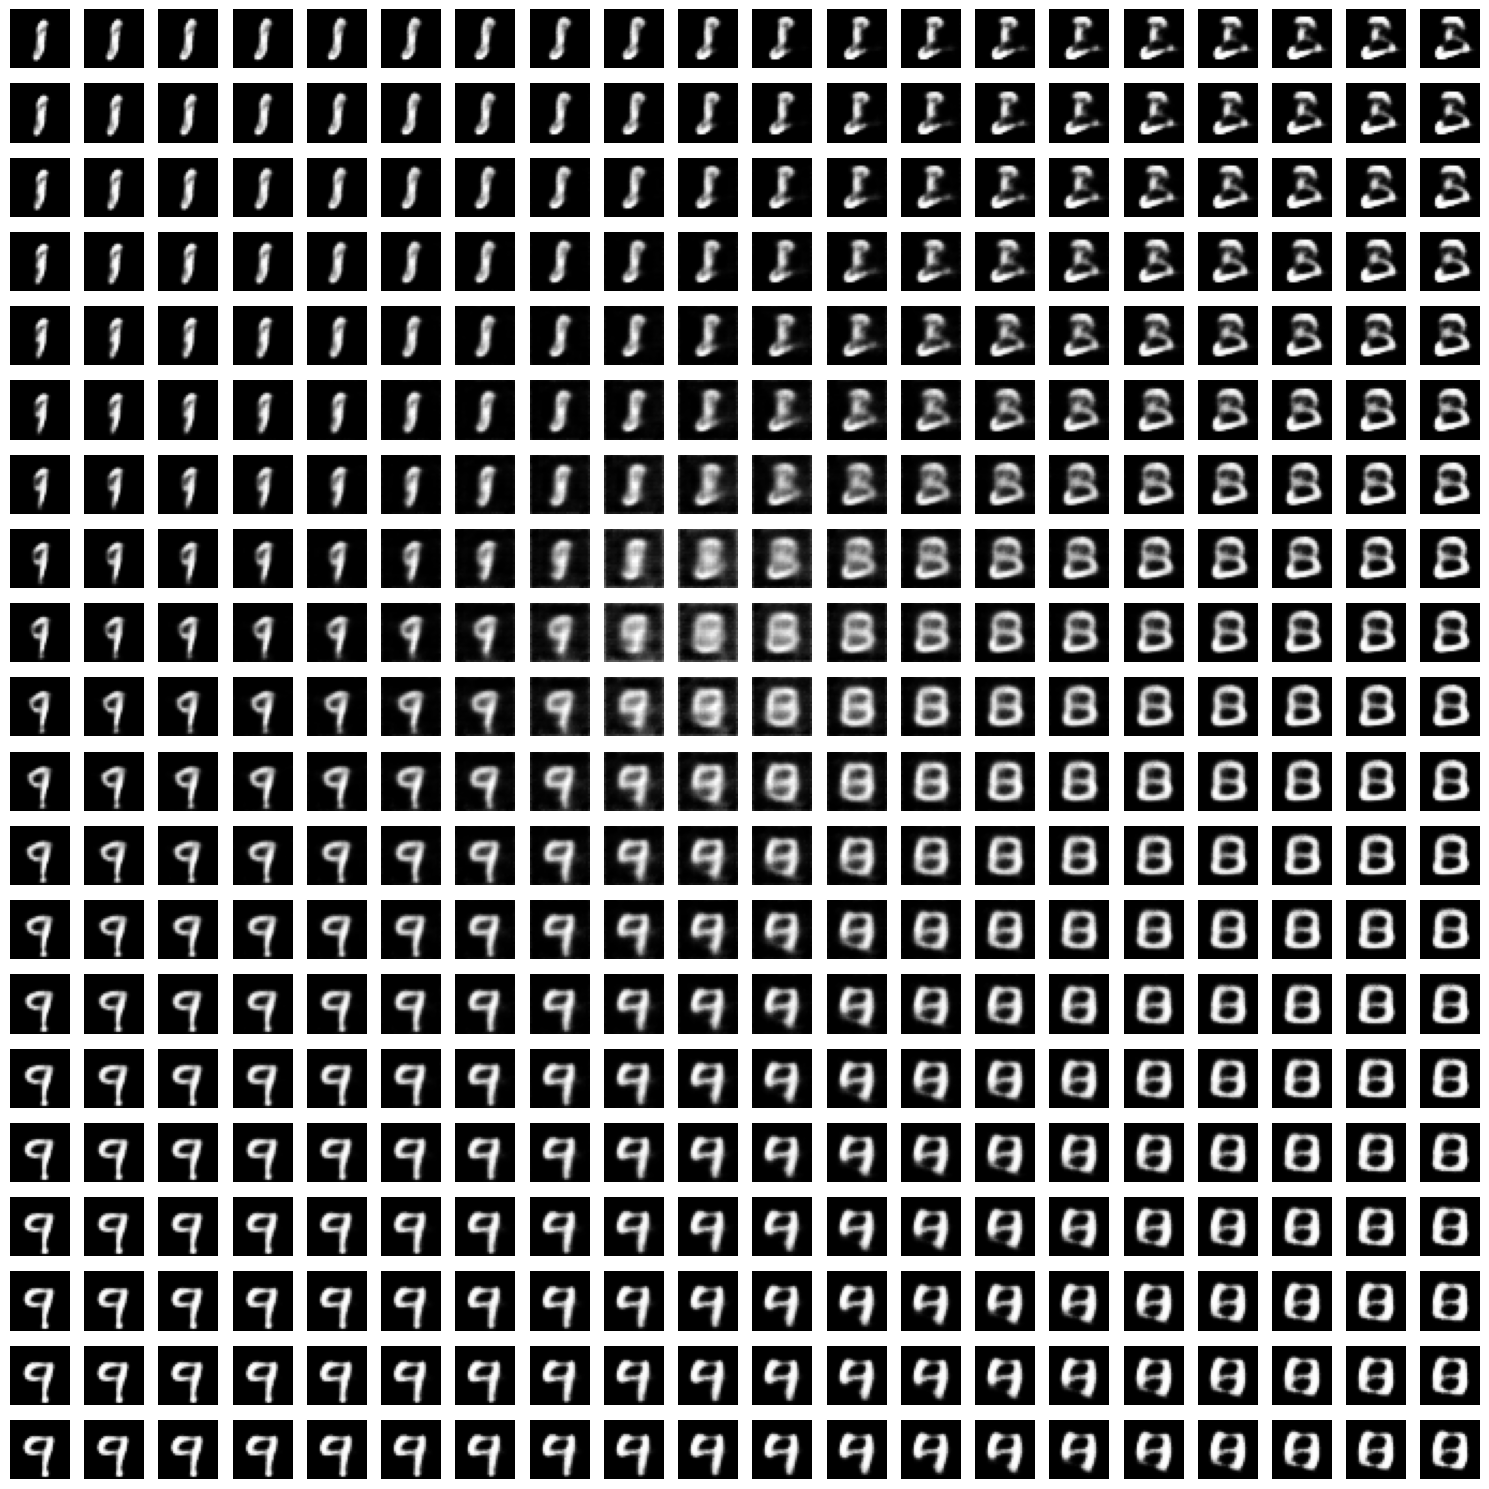

In [31]:
dim1 = 0
dim2 = 1
n_steps = 20

fig, axes = plt.subplots(n_steps, n_steps, figsize=(15, 15))

walk_dim1 = torch.linspace(C[:, dim1].min(), C[:, dim1].max(), steps=n_steps).to(opt.device)
walk_dim2 = torch.linspace(C[:, dim2].min(), C[:, dim2].max(), steps=n_steps).to(opt.device)

with torch.no_grad():
    for row in range(n_steps):
        for col in range(n_steps):
            z_walk = torch.zeros(1, opt.h_dim, device=opt.device).double()  # Start with a zero vector
            z_walk[0, dim1] = walk_dim1[col]   # columns
            z_walk[0, dim2] = walk_dim2[row]   # rows

            x_tilde_walk = net3(torch.mm(z_walk, U_test.t()))
            axes[row, col].imshow(x_tilde_walk[0].cpu().numpy().reshape(28, 28), cmap='gray')
            axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('./img/lv/1V-12.png', dpi=300)
plt.show()

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_65334/1676585823.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  z_base = torch.tensor(C.mean(axis=0), device=opt.device).unsqueeze(0).double()


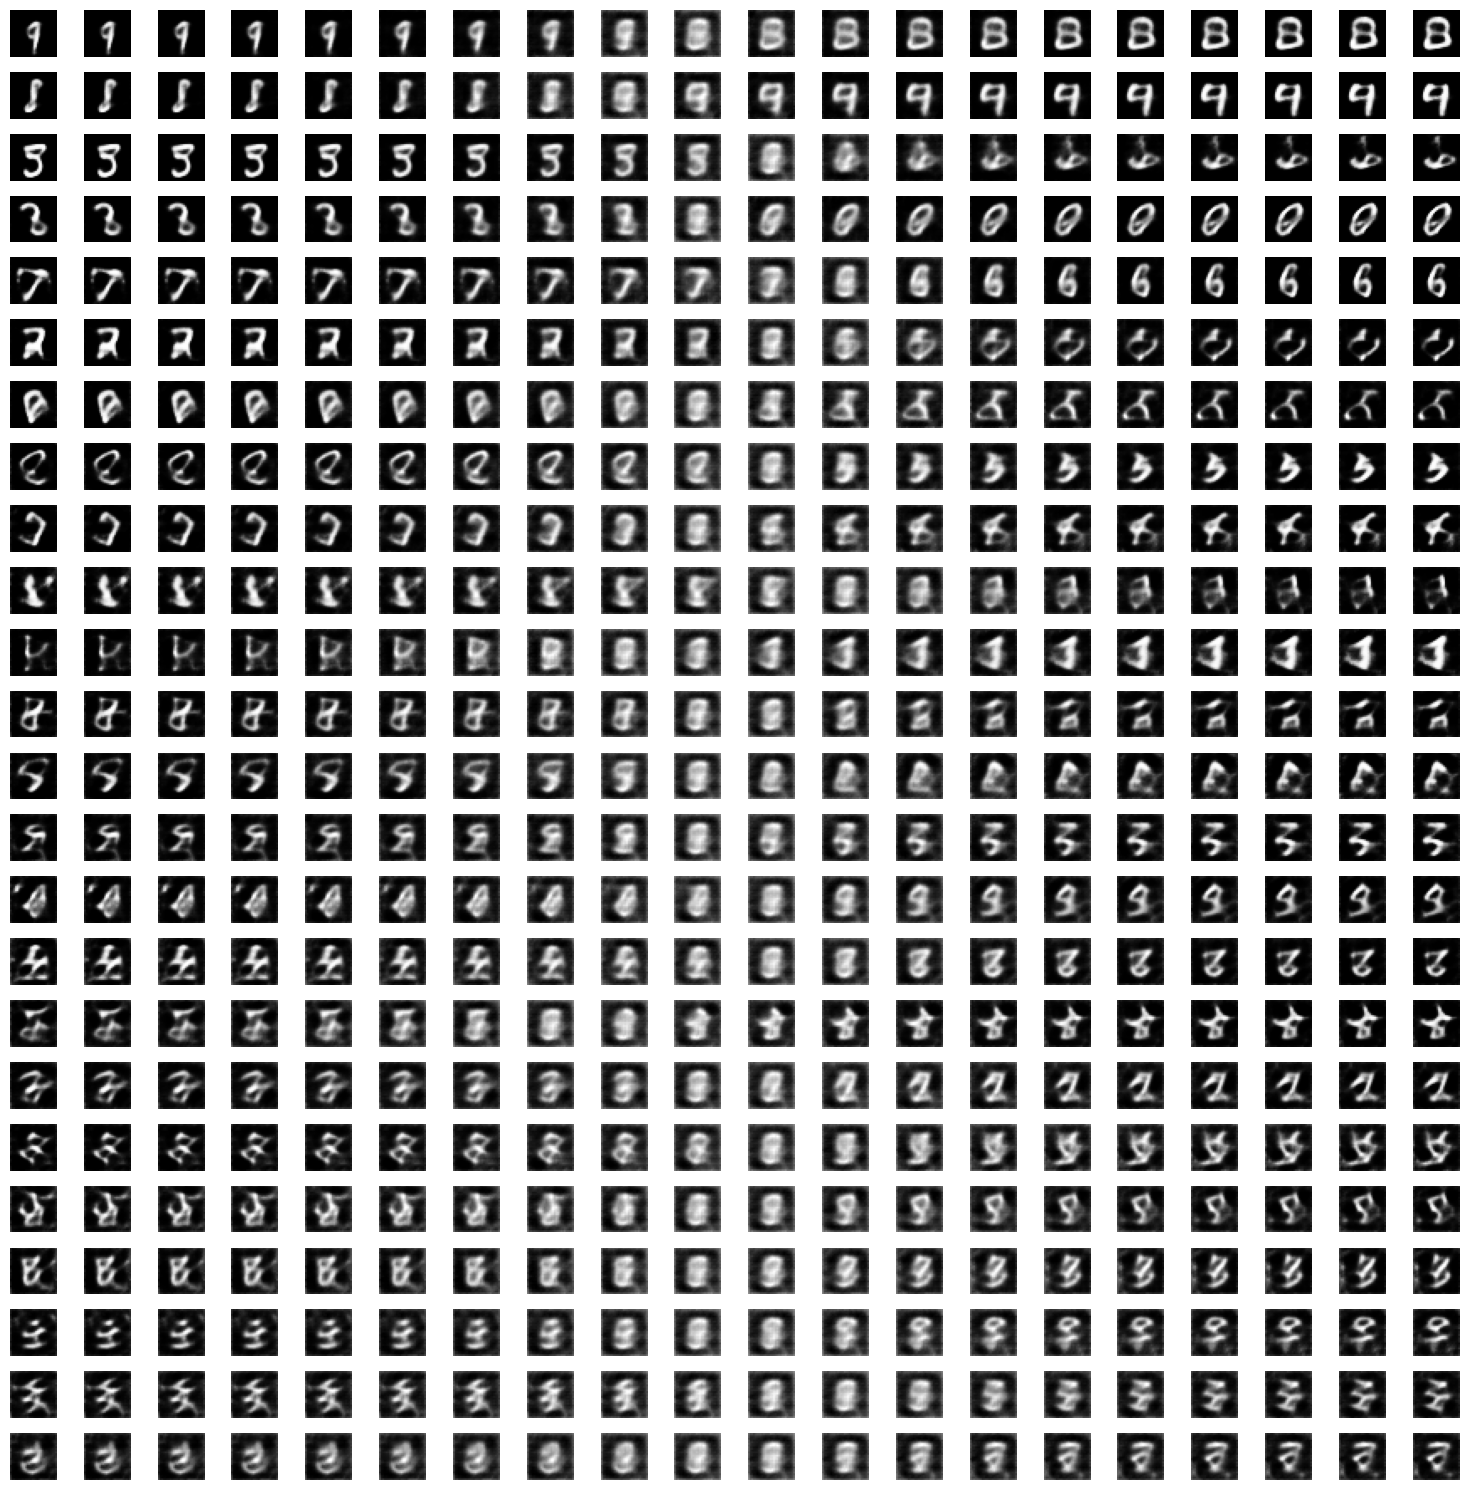

In [32]:
fig, axes = plt.subplots(opt.h_dim, n_steps, figsize=(15, 15))

with torch.no_grad():
    for dim in range(opt.h_dim):
        walk_dim = torch.linspace(C[:, dim].min(), C[:, dim].max(), steps=n_steps).to(opt.device)

        for step in range(n_steps):
            z_base = torch.tensor(C.mean(axis=0), device=opt.device).unsqueeze(0).double()
            z_walk = z_base.clone()
            z_walk[0, dim] = walk_dim[step]

            x_tilde_walk = net3(torch.mm(z_walk, U_test.t()))

            axes[dim, step].imshow(x_tilde_walk[0].cpu().numpy().reshape(28, 28), cmap='gray')
            axes[dim, step].axis('off')

plt.tight_layout()
plt.savefig('./img/lv/1V-A.png', dpi=300)
plt.show()
